In [7]:
import scipy as sp
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sb
import plotly.express as px
import pingouin as pg
from pingouin import qqplot

## Задача 1. 
Генерирайте $n=1000$ стойности от едномерно нормално разпределение с $\mu=2$ и $\sigma^2=4$. Тествайте за нормалност чрез Shapiro-Wilks (имплементиран е в библиотеката scipy).

Генерирайте $N=100000$ надлюдения над статистиката на Shapiro-Wilks теста за случайни нормално разпределени извадки с размер $n=1000$. Начертайте хистограма като оцветите стойностите, при които бихме отхвърлили хипотезата, че извадката е нормална, в червено.

In [2]:
# Генериране на данни от едномерно нормално разпределение
n = 1000
mu = 2
var = 4
sigma = np.sqrt(var)

sample_norm = sp.stats.norm.rvs(loc=mu, scale=sigma, size=n, random_state=42)

# Тест за нормалност
result = sp.stats.shapiro(sample_norm)

print(f"Shapiro-Wilk statistic: {result.statistic}")
print(f"p-value:                {result.pvalue}")

# p > 0.05: не отхвърляме нулевата хипотеза за нормалност

Shapiro-Wilk statistic: 0.9986092190723586
p-value:                0.627257839297054


In [3]:
# Приготвяме фунция за статистиката на Шапиро-Уилкс
def statistic(x):
    return sp.stats.shapiro(x).statistic

# Фунция за начертаване на хистограмата с оцветяване на колоните при зададено ниво на значимост
def histogram_with_cdf_coloring(data, bins=100, alpha=0.05):
    density, bins, patches = plt.hist(data, bins=bins, density=True)

    step = bins[1] - bins[0]
    probabilities = step * density
    cdf = np.cumsum(probabilities) # Пресмятаме кумулативната вероятностна функция от данните

    for cdf_value, patch in zip(cdf, patches):
        patch.set_facecolor('red' if cdf_value <= alpha else None)

    plt.xlabel('Statistic Value')
    plt.ylabel('Density')
    plt.show()

In [4]:
# Тест на Шапиро-Уилкс чрез Монте-Карло симулация
N = 100000

rng = np.random.default_rng(seed=5)

mc_samples = sp.stats.norm.rvs(loc=mu, scale=sigma, size=(N, n), random_state=rng)
null_distribution = np.apply_along_axis(lambda row: statistic(row), 1, mc_samples)
    
print(f"Sample statistic: {result.statistic}")
print(f"Monte Carlo p-value: {np.mean(null_distribution <= result.statistic)}")
print(f"Null distribution: {null_distribution.shape}")

Sample statistic: 0.9986092190723586
Monte Carlo p-value: 0.64029
Null distribution: (100000,)


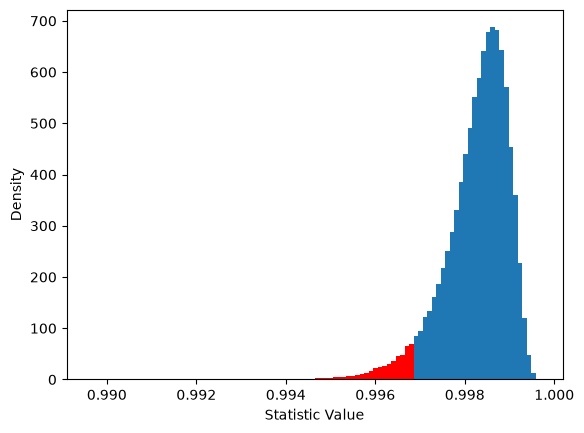

In [5]:
histogram_with_cdf_coloring(null_distribution, bins=100, alpha=0.05)

In [6]:
# Алтернативен метод с вградената функция на SciPy за Монте-Карло тест
rng = np.random.default_rng(seed=5)

rvs = lambda size: sp.stats.norm.rvs(loc=mu, scale=sigma, size=size, random_state=rng)

mc = sp.stats.monte_carlo_test(sample_norm, rvs, statistic=statistic, vectorized=False, n_resamples=N, alternative='less')

print(f"Sample statistic: {mc.statistic}")
print(f"Monte Carlo p-value: {mc.pvalue}")
print(f"Null distribution: {mc.null_distribution.shape}")

Sample statistic: 0.9986092190723586
Monte Carlo p-value: 0.6402935970640293
Null distribution: (100000,)


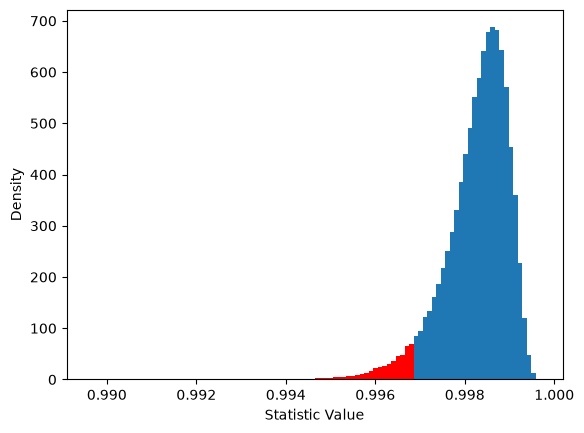

In [7]:
histogram_with_cdf_coloring(mc.null_distribution, bins=100, alpha=0.05)

## Задача2. 
Генерирайте $n=1000$ стойности от двумерно нормално разпределение с $\mu=(2, -5)$ и $\sigma^2=\begin{bmatrix} 100 & 100 \\ 100 & 265 \end{bmatrix}$. Тествайте за нормалност.

In [2]:
n = 1000
mu = [2, -5]
cov = [[100, 100], [100, 265]]

sample_multivariate_norm_2 = sp.stats.multivariate_normal.rvs(mean=mu, cov=cov, size=n, random_state=24)

In [3]:
def squared_mahalanobis_distance(X):
    mean = np.mean(X, axis=0)
    cov = np.cov(X, rowvar=False)
    inv_cov = np.linalg.inv(cov)
    return np.sum((X - mean) @ inv_cov * (X - mean), axis=1)

In [6]:
d_squared = squared_mahalanobis_distance(sample_multivariate_norm_2)

<Axes: xlabel='Theoretical quantiles', ylabel='Ordered quantiles'>

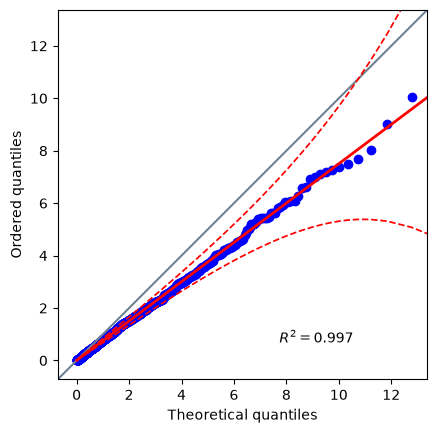

In [9]:
qqplot(d_squared, 'chi2', sparams=(len(mu),))

In [ ]:
# Приблизителен тест с генерализираните разстояния спрямо χ²-разпределение
ks = sp.stats.kstest(d_squared, 'chi2', args=(len(mu),))

print(f"KS statistic: {ks.statistic}")
print(f"p-value:      {ks.pvalue}")

KS statistic: 0.018625103870709814
p-value:      0.8719436543033423


In [ ]:
# По-точен тест за нормалност при многомерни данни
pg.multivariate_normality(sample_multivariate_norm_2)

HZResults(hz=np.float64(0.3889840733039135), pval=np.float64(0.9919819749634637), normal=True)

## Задача 3.

Визуализирайте данните от Зад. 2
- чрез отделни точки (scatterplot)
- чрез диаграма на плътността (heatmap)
- чрез линиите на ниво на плътността

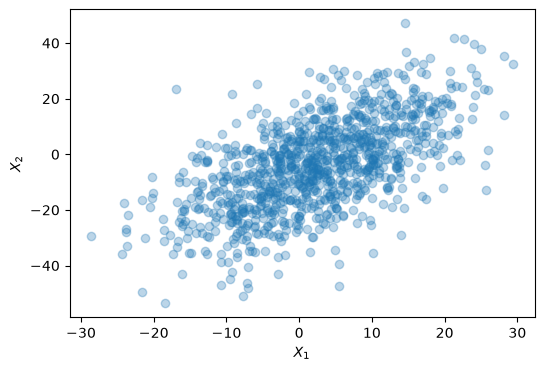

In [11]:
plt.figure(figsize=(6,4))
plt.scatter(sample_multivariate_norm_2[:, 0], sample_multivariate_norm_2[:, 1], alpha=0.3)
plt.xlabel('$X_1$')
plt.ylabel('$X_2$')
plt.show()

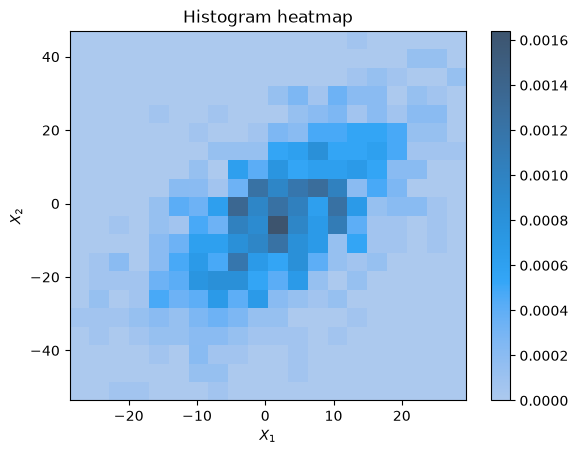

In [12]:
df = pd.DataFrame(sample_multivariate_norm_2, columns=['X1', 'X2'])

sb.histplot(df, x='X1', y='X2', bins=20, cbar=True, stat='density', thresh=None)
plt.title('Histogram heatmap')
plt.xlabel('$X_1$')
plt.ylabel('$X_2$')
plt.show()

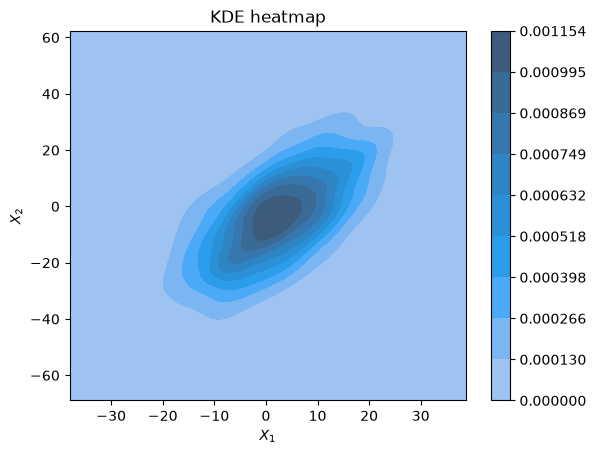

In [13]:
sb.kdeplot(df, x='X1', y='X2', fill=True, thresh=0, levels=10, cbar=True)
plt.title('KDE heatmap')
plt.xlabel('$X_1$')
plt.ylabel('$X_2$')
plt.show()

## Задача 4. 
Генерирайте $n=500$ стойности от тримерно нормално разпределение с $\mu=(-10, 4, 123)$ и $\sigma^2=\begin{bmatrix} 21 & 4 & -2 \\ 4 & 21 & 17 \\ -2 & 17 & 18 \end{bmatrix}$. Тествайте за нормалност.

In [11]:
n = 500
mu = [-10, 4, 123]
cov = [[21, 4, -2], [4, 21, 17], [-2, 17, 18]]

sample_multivariate_norm_3 = sp.stats.multivariate_normal.rvs(mean=mu, cov=cov, size=n, random_state=24)

In [13]:
d_squared = squared_mahalanobis_distance(sample_multivariate_norm_3)

ks = sp.stats.kstest(d_squared, 'chi2', args=(len(mu),))

print(f"KS statistic: {ks.statistic}")
print(f"p-value:      {ks.pvalue}")

KS statistic: 0.03782435543670973
p-value:      0.460577589956787


In [14]:
pg.multivariate_normality(sample_multivariate_norm_3)

HZResults(hz=np.float64(0.8026871654049951), pval=np.float64(0.5586962194719699), normal=True)

## Задача 5.
Визуализирайте данните от Зад. 4 чрез интерактивен триизмерен scatterplot.

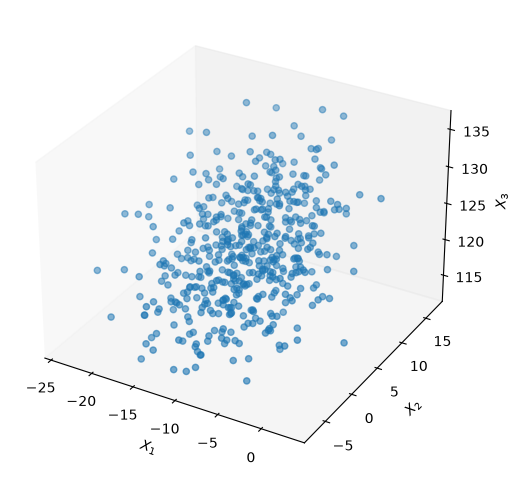

In [16]:
# Инсталирайте бибилиотеката `ipympl` и използвайте магическата команда за интерактивен плот:
# %matplotlib widget 

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

xs = sample_multivariate_norm_3[:, 0]
ys = sample_multivariate_norm_3[:, 1]
zs = sample_multivariate_norm_3[:, 2]

ax.scatter(xs, ys, zs, alpha=0.8)
ax.set_xlabel('$X_1$')
ax.set_ylabel('$X_2$')
ax.set_zlabel('$X_3$')
ax.grid(False)

plt.show()

In [17]:
# Create DataFrame matching your variables
df = pd.DataFrame({
    'X1': sample_multivariate_norm_3[:, 0],
    'X2': sample_multivariate_norm_3[:, 1],
    'X3': sample_multivariate_norm_3[:, 2]
})

# Create 3D scatter plot
fig = px.scatter_3d(
    df, 
    x='X1', 
    y='X2', 
    z='X3',
    size_max=0.2,
    opacity=0.8,
)

fig.update_layout(
    width=900,
    height=900,
    margin=dict(l=0, r=0, t=0, b=0),
    scene=dict(
        xaxis_title='X<sub>1</sub>',
        yaxis_title='X<sub>2</sub>',
        zaxis_title='X<sub>3</sub>',
        camera=dict(
            eye=dict(x=1.25, y=1.5, z=1.25),  # Increasing x, y, z zoom values moves the camera back
            center=dict(x=0, y=0, z=0)
        )
    )
)

fig.update_traces(marker=dict(size=3))

fig.show()

## Задача 6. 
Генерирайте $n=500$ стойности от четиримерно нормално разпределение с произволен среден вектор и ковариационна матрица. Тествайте за нормалност.

(ковариационната матрица трябва да е симетрична и с неотрицателна детерминанта. Как може да генерирате произволна матрица, която изпълнява тези свойства?)

In [53]:
np.random.seed(24)

n = 500
p = 4

mu = np.random.uniform(-5, 5, p)
print(mu)

A = np.random.uniform(-2, 2, (4, 4))
sigma = A @ A.T
print(sigma)

[ 4.60017303  1.9951205   4.99867293 -2.799327  ]
[[ 5.71241211 -0.67035877  2.08300597 -0.96312011]
 [-0.67035877  3.12990122 -1.5198201  -2.07685295]
 [ 2.08300597 -1.5198201   4.30547275 -0.59607623]
 [-0.96312011 -2.07685295 -0.59607623  3.0390454 ]]


In [54]:
A = np.random.uniform(-3, 3, (4, 4))
sigma = A @ A.T

In [55]:
sample_multivariate_norm_4 = sp.stats.multivariate_normal.rvs(mean=mu, cov=sigma, size=n, random_state=48)

In [56]:
d_squared = squared_mahalanobis_distance(sample_multivariate_norm_4)

ks = sp.stats.kstest(d_squared, 'chi2', args=(len(mu),))

print(f"KS statistic: {ks.statistic}")
print(f"p-value:      {ks.pvalue}")

KS statistic: 0.026989229169448764
p-value:      0.84974130353319


In [57]:
pg.multivariate_normality(sample_multivariate_norm_4)

HZResults(hz=np.float64(0.7626355261706602), pval=np.float64(0.9475731397089594), normal=True)

In [ ]:
# Пример с данни от различно разпределение (триъгълно)
np.random.seed(24)
sample_multivariate_triang = np.random.triangular(left=0, mode=1, right=2, size=(500, p))

In [ ]:
# Тест на Kolmogorov-Smirnov за многомерна нормалност чрез спрямо χ²-разпределението не отхвърля хипотезата за нормалност при дадената извадка от триъгълно разпределение.
d_squared = squared_mahalanobis_distance(sample_multivariate_triang)

ks = sp.stats.kstest(d_squared, 'chi2', args=(len(mu),))

print(f"KS statistic: {ks.statistic}")
print(f"p-value:      {ks.pvalue}")

KS statistic: 0.05325415552031654
p-value:      0.11314453302712513


In [ ]:
# Тест на Henze-Zirkler за многомерна нормалност отхвърля хипотезата за нормалност при дадената извадка от триъгълно разпределение.
pg.multivariate_normality(sample_multivariate_triang)

HZResults(hz=np.float64(1.114404939877741), pval=np.float64(0.009108562631494531), normal=False)

## Задача 7. 
Визуализирайте данните от горната задача чрез тримерен scatterplot, като използвате цвета на точките за да покажата четвъртата компонента на данните.

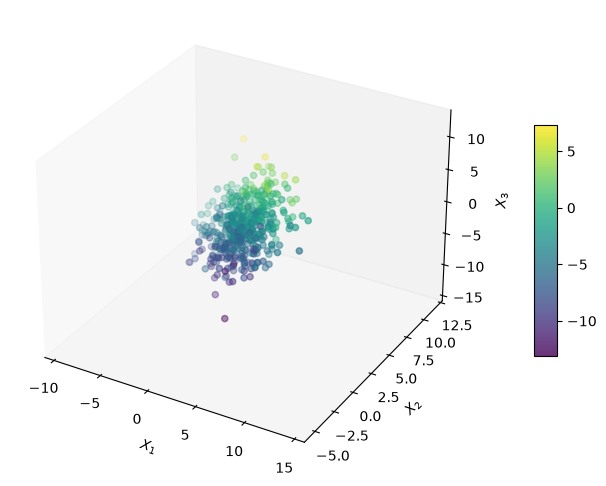

In [22]:
# Тази линия вече не е необходима, тъй като вече сме я използвали по-горе.
# %matplotlib widget 

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

xs = sample_multivariate_norm_4[:, 0]
ys = sample_multivariate_norm_4[:, 1]
zs = sample_multivariate_norm_4[:, 2]

sc = ax.scatter(xs, ys, zs, alpha=0.8, c=sample_multivariate_norm_4[:, 3], cmap='viridis')
ax.set_xlabel('$X_1$')
ax.set_ylabel('$X_2$')
ax.set_zlabel('$X_3$')
ax.grid(False)

cbar = fig.colorbar(sc, ax=ax, shrink=0.5, aspect=10, pad=0.1)

plt.show()

In [23]:
# Create DataFrame matching your variables
df = pd.DataFrame({
    'X1': sample_multivariate_norm_4[:, 0],
    'X2': sample_multivariate_norm_4[:, 1],
    'X3': sample_multivariate_norm_4[:, 2]
})

# Create 3D scatter plot
fig = px.scatter_3d(
    df, 
    x='X1', 
    y='X2', 
    z='X3',
    color=sample_multivariate_norm_4[:, 3],
    size_max=0.2,
    opacity=0.8,
)

fig.update_layout(
    width=900,
    height=900,
    margin=dict(l=0, r=0, t=0, b=0),
    scene=dict(
        xaxis_title='X<sub>1</sub>',
        yaxis_title='X<sub>2</sub>',
        zaxis_title='X<sub>3</sub>',
        camera=dict(
            eye=dict(x=1.5, y=1.75, z=1.5),  # Increasing x, y, z zoom values moves the camera back
            center=dict(x=0, y=0, z=0)
        )
    ),
    coloraxis_colorbar=dict(len=0.6)
)

fig.update_traces(marker=dict(size=3))

fig.show()